In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set(style='whitegrid')
plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [2]:
import os

file_path = os.path.join("..", "data", "processed", "feature_engineered_crime_data.csv")

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print(df.head())
print(df.info())


Dataset Shape: (743328, 32)
       DR_NO   Date Rptd    DATE OCC  TIME OCC  AREA    AREA NAME  \
0   10304468  2020-01-08  2020-01-08      2230     3    Southwest   
1  190101086  2020-01-02  2020-01-01       330     1      Central   
2  200110444  2020-04-14  2020-02-13      1200     1      Central   
3  191501505  2020-01-01  2020-01-01      1730    15  N Hollywood   
4  191921269  2020-01-01  2020-01-01       415    19      Mission   

   Rpt Dist No  Part 1-2  Crm Cd  \
0          377         2     624   
1          163         2     624   
2          155         2     845   
3         1543         2     745   
4         1998         2     740   

                                         Crm Cd Desc  ...      LAT       LON  \
0                           BATTERY - SIMPLE ASSAULT  ...  34.0141 -118.2978   
1                           BATTERY - SIMPLE ASSAULT  ...  34.0459 -118.2545   
2          SEX OFFENDER REGISTRANT OUT OF COMPLIANCE  ...  34.0448 -118.2474   
3           VANDALIS

<class 'pandas.DataFrame'>
RangeIndex: 743328 entries, 0 to 743327
Data columns (total 32 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   DR_NO               743328 non-null  int64  
 1   Date Rptd           743328 non-null  str    
 2   DATE OCC            743328 non-null  str    
 3   TIME OCC            743328 non-null  int64  
 4   AREA                743328 non-null  int64  
 5   AREA NAME           743328 non-null  str    
 6   Rpt Dist No         743328 non-null  int64  
 7   Part 1-2            743328 non-null  int64  
 8   Crm Cd              743328 non-null  int64  
 9   Crm Cd Desc         743328 non-null  str    
 10  Mocodes             743328 non-null  str    
 11  Vict Age            743328 non-null  int64  
 12  Vict Sex            743328 non-null  str    
 13  Vict Descent        743328 non-null  str    
 14  Premis Cd           743328 non-null  float64
 15  Premis Desc         743328 non-null  str    


In [3]:

df['Crime Hour'] = (df['TIME OCC'] // 100).astype(int)
df['Crime Hour'] = df['Crime Hour'].clip(0,23)

print(df.describe())
print(df.isnull().sum())

              DR_NO       TIME OCC           AREA    Rpt Dist No  \
count  7.433280e+05  743328.000000  743328.000000  743328.000000   
mean   2.145836e+08    1335.056976      10.717219    1118.116542   
std    1.018982e+07     653.550059       6.092492     609.256096   
min    8.170000e+02       1.000000       1.000000     101.000000   
25%    2.021078e+08     900.000000       6.000000     622.000000   
50%    2.118207e+08    1415.000000      11.000000    1142.000000   
75%    2.214131e+08    1900.000000      16.000000    1618.000000   
max    2.399165e+08    2359.000000      21.000000    2199.000000   

            Part 1-2         Crm Cd       Vict Age      Premis Cd  \
count  743328.000000  743328.000000  743328.000000  743328.000000   
mean        1.416130     501.008875      29.932155     305.876356   
std         0.492916     207.972003      21.720165     216.840197   
min         1.000000     110.000000       0.000000     101.000000   
25%         1.000000     331.000000      1

DR_NO                 0
Date Rptd             0
DATE OCC              0
TIME OCC              0
AREA                  0
AREA NAME             0
Rpt Dist No           0
Part 1-2              0
Crm Cd                0
Crm Cd Desc           0
Mocodes               0
Vict Age              0
Vict Sex              0
Vict Descent          0
Premis Cd             0
Premis Desc           0
Weapon Used Cd        0
Weapon Desc           0
Status                0
Status Desc           0
Crm Cd 1              0
LOCATION              0
LAT                   0
LON                   0
Crime Hour            0
Day of Week           0
Month                 0
Month Name            0
Year                  0
Weapon Used Flag      0
Violent Crime Flag    0
Area Crime Count      0
dtype: int64


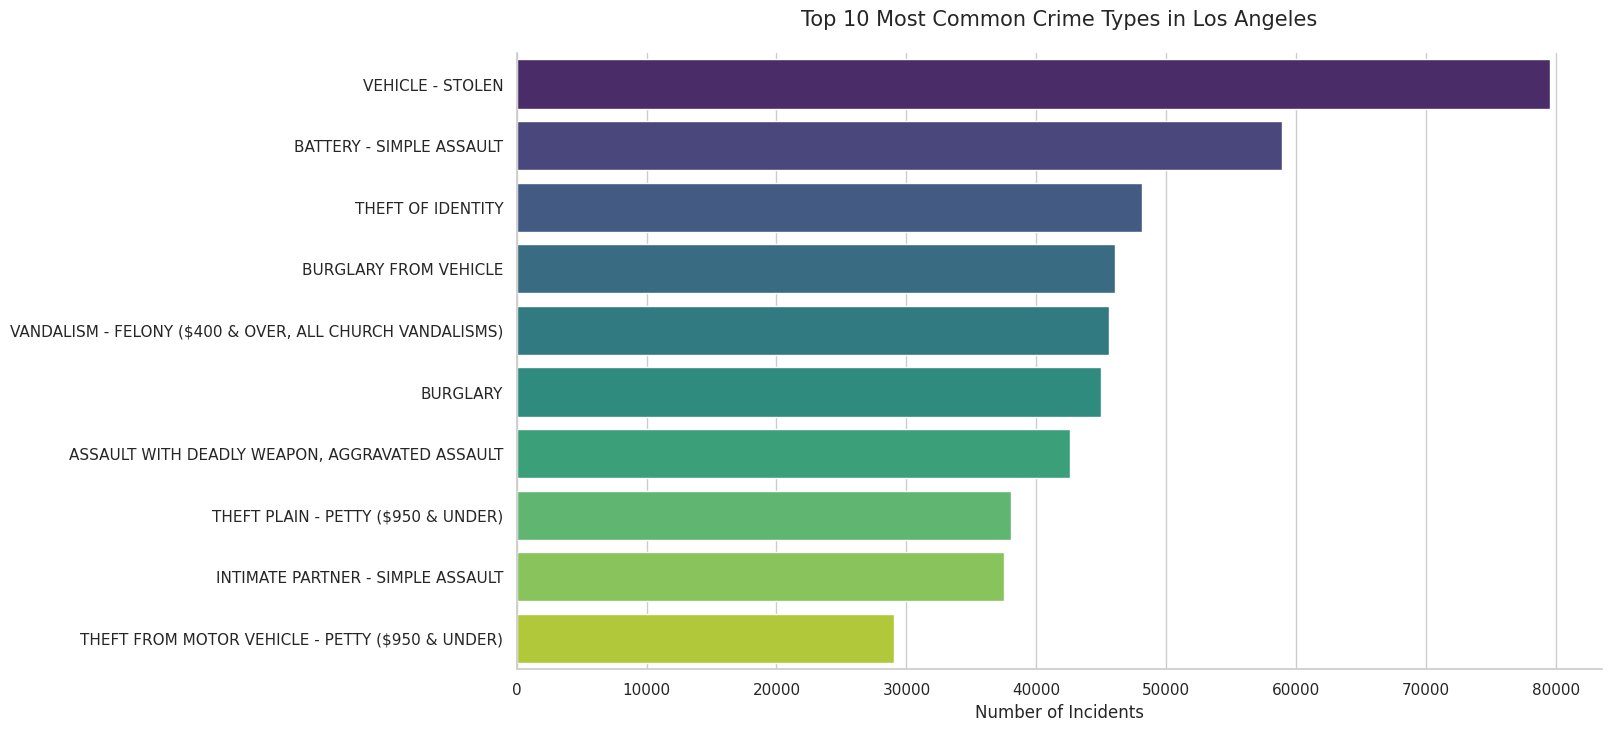

In [4]:
# Top 10 Crime Types

top_crimes = df['Crm Cd Desc'].value_counts().head(10)

plt.figure(figsize=(14, 8))
sns.barplot(
    x=top_crimes.values, 
    y=top_crimes.index, 
    hue=top_crimes.index,  # Assigning y to hue fixes the warning
    palette='viridis',     # 'viridis' or 'mako' looks very professional
    legend=False           # Removes the redundant legend
)

# Professional touches
plt.title("Top 10 Most Common Crime Types in Los Angeles", fontsize=15, pad=20)
plt.xlabel("Number of Incidents", fontsize=12)
plt.ylabel("") # Removing the y-label often looks cleaner for horizontal bars
sns.despine()  # Removes the top and right border lines
plt.show()


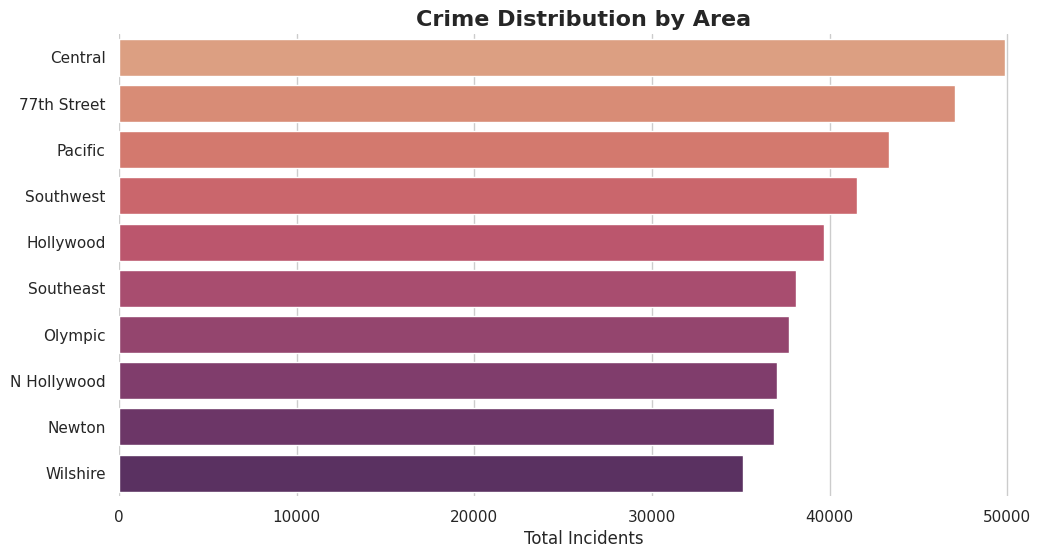

In [5]:
# Top Dangerous Areas

top_areas = df['AREA NAME'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_areas.values, 
    y=top_areas.index, 
    hue=top_areas.index, 
    palette="flare", # '_r' reverses it so the highest count is the darkest blue
    legend=False
)
plt.title("Crime Distribution by Area", fontsize=16, fontweight='bold', loc='center')
plt.xlabel("Total Incidents", fontsize=12)
plt.ylabel("") 
sns.despine(left=True, bottom=True) # Removes the box for a modern, "airy" look
plt.show()


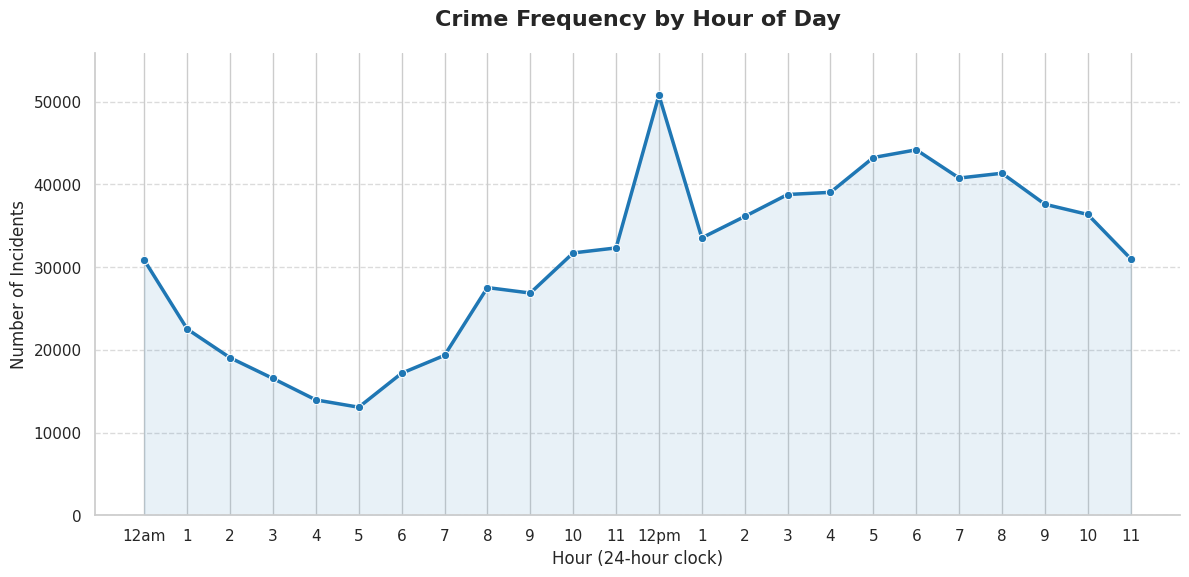

In [6]:
# Crime by Hour
df['Crime Hour'] = (df['TIME OCC'] // 100).astype(int)
df['Crime Hour'] = df['Crime Hour'].clip(0,23)
hourly_crime = df['Crime Hour'].value_counts().sort_index()

plt.figure(figsize=(14, 6))

# 1. Use a clean line with markers to show exactly where data points sit
sns.lineplot(x=hourly_crime.index, y=hourly_crime.values, 
             marker='o', color='#1f77b4', linewidth=2.5)

# 2. Fill with a soft gradient
plt.fill_between(hourly_crime.index, hourly_crime.values, color='#1f77b4', alpha=0.1)

# 3. Force Y-axis to start at 0 so you don't mislead the viewer
plt.ylim(0, max(hourly_crime.values) * 1.1)


plt.title("Crime Frequency by Hour of Day", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Hour (24-hour clock)", fontsize=12)
plt.ylabel("Number of Incidents", fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7) # Grid helps see the "up/down" levels
sns.despine()
# This keeps the logic but makes the labels easier to read
plt.xticks(ticks=range(0, 24), 
           labels=['12am', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', 
                   '12pm', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11'])


plt.show()


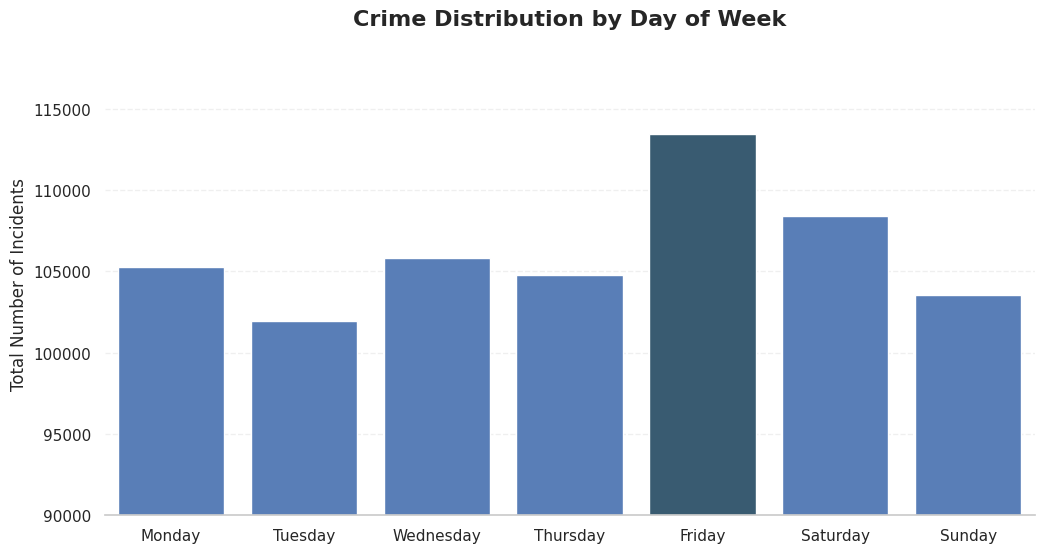

In [7]:
# # Crime by Day of Week

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_crime = df['Day of Week'].value_counts().reindex(day_order)


# 1. Create a color list where the max value is highlighted

colors = ["#497BC7" if x < day_crime.max() else '#305D7A' for x in day_crime.values]

plt.figure(figsize=(12, 6))

# 2. Use 'edgecolor' to give bars definition without looking cheap
sns.barplot(
    x=day_crime.index, 
    y=day_crime.values, 
    palette=colors,
    hue=day_crime.index,
    legend=False
)


plt.title("Crime Distribution by Day of Week", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Total Number of Incidents", fontsize=12)
plt.xlabel("") 
plt.xticks(rotation=0) # Keep text straight for better readability
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine(left=True) # Remove left border for a "modern" feel

# 4. Force the Y-axis to start at a certain point to show the 'gap' better
# (Optional: Only if you want to emphasize the difference between days)
plt.ylim(90000, day_crime.max() + 5000) 

plt.show()


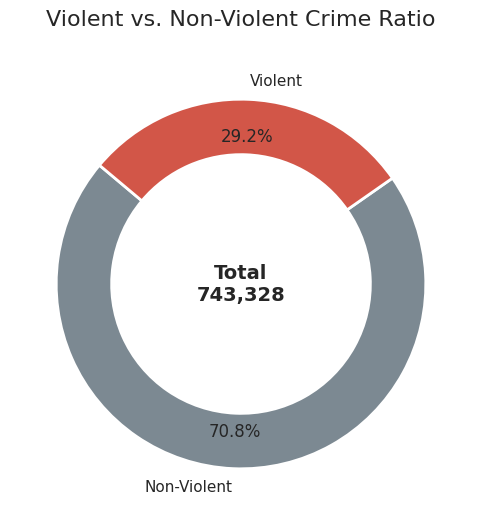

In [8]:
# Violent vs Non-Violent Crime

violent_counts = df['Violent Crime Flag'].value_counts()


# 1. Colors: Deep Red for Violent, Light Slate for Non-Violent
colors = ["#7C8992", "#D25648"] 

plt.figure(figsize=(6, 6))
plt.pie(
    violent_counts,
    labels=['Non-Violent', 'Violent'],
    autopct='%1.1f%%',
    startangle=140,      # Rotates the chart for a better starting view
    colors=colors,
    pctdistance=0.80,    # Moves percentages into the middle of the ring
    wedgeprops={'width': 0.3, 'edgecolor': 'w', 'linewidth': 2} # Thinner ring, clean edges
)

# 2. Add a center label (Common in high-end reports)
total_crimes = violent_counts.sum()
plt.text(0, 0, f'Total\n{total_crimes:,}', ha='center', va='center', fontsize=14, fontweight='bold')

plt.title("Violent vs. Non-Violent Crime Ratio", fontsize=16, pad=20)
plt.show()


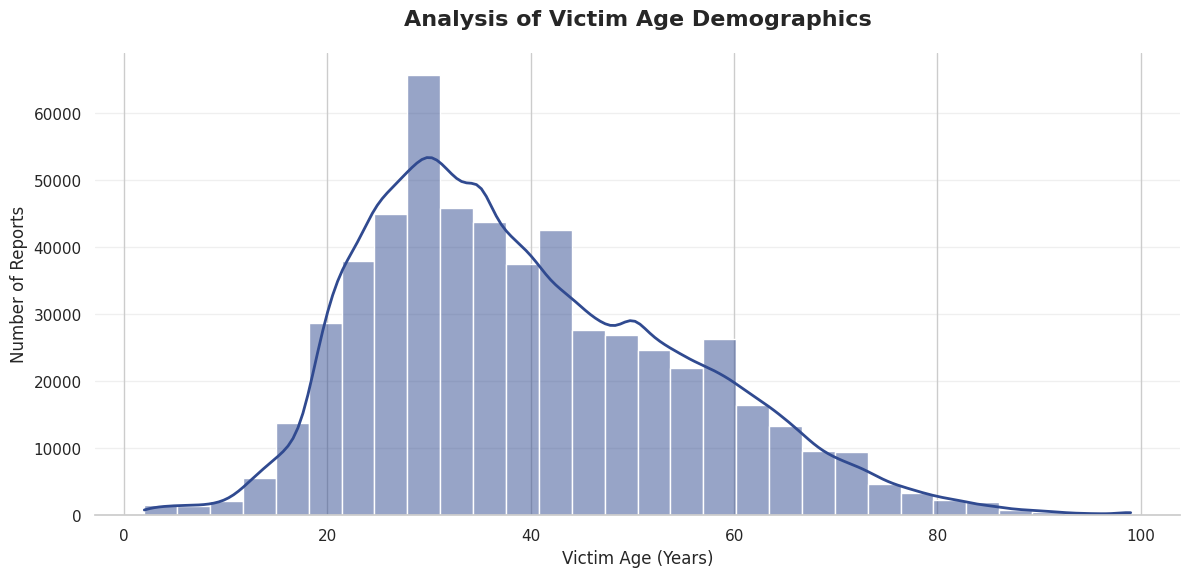

In [9]:
# Victim Age Distribution
age_df = df[df['Vict Age'] > 0]
plt.figure(figsize=(14, 6))

# 1. Use a more professional color and adjust 'alpha' for a softer look
sns.histplot(
    age_df['Vict Age'], 
    bins=30, 
    kde=True, 
    color="#304A90", 
    line_kws={'linewidth': 2}, 
    edgecolor='white'          # Adds clean separation between bars
)


plt.title("Analysis of Victim Age Demographics", fontsize=16, fontweight='bold', pad=20, loc='center')
plt.xlabel("Victim Age (Years)", fontsize=12)
plt.ylabel("Number of Reports", fontsize=12)

# 3. Clean up the "frame"
sns.despine(left=True) # Modern look: removes the left and top border
plt.grid(axis='y', alpha=0.3) # Only horizontal lines for easy reading

plt.show()


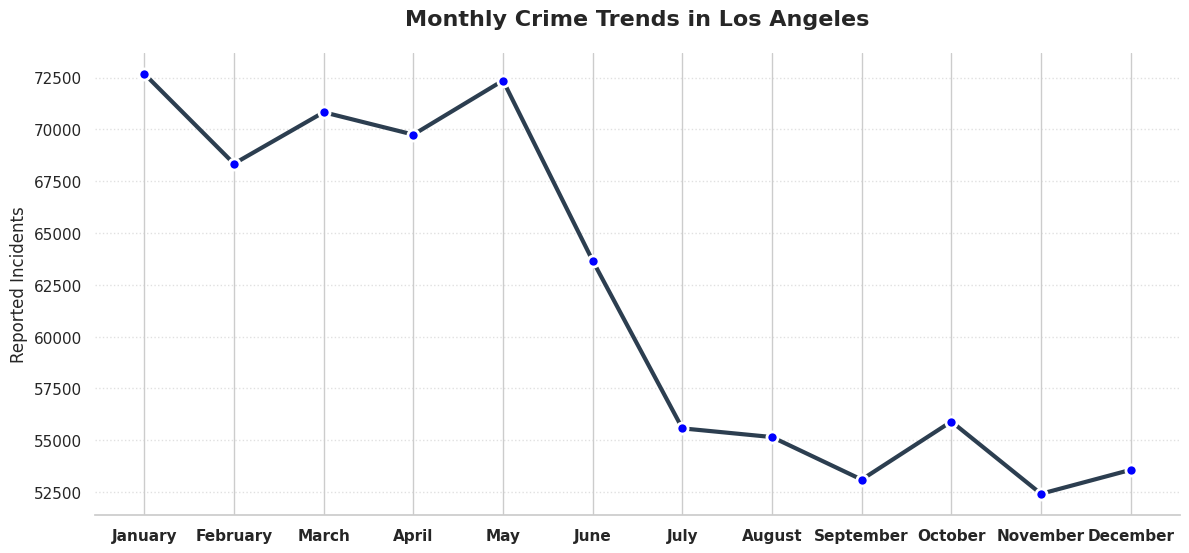

In [10]:
# Monthly Crime Trends

monthly_crime = df.groupby('Month Name').size()

month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_crime = monthly_crime.reindex(month_order)

plt.figure(figsize=(14,6))
sns.lineplot(
    x=monthly_crime.index,
    y=monthly_crime.values,
    marker='o',
    markersize=8,
    markerfacecolor='blue', # Hollow markers look very professional
    markeredgewidth=2,
    linewidth=3, 
    color='#2C3E50'
)
plt.title("Monthly Crime Trends in Los Angeles", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("")
plt.ylabel("Reported Incidents", fontsize=12)
plt.xticks(rotation=0, fontsize=11, fontweight='bold')
plt.grid(axis='y', linestyle=':', alpha=0.6)
sns.despine(left=True, bottom=False)
plt.show()